## Подготовка

### Импорты, seed и среда

In [54]:
import os
import json
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [3]:
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [4]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

SEED = 42
seed_everything(SEED)

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)

device: cpu


In [6]:
os.makedirs("artifacts/figures/", exist_ok=True)

### Данные и первичный анализ

In [7]:
df = pd.read_csv("S12-hw-dataset.csv")
df

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [9]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [11]:
print(f"Количество наблюдений: {len(df)}")
print(f"Диапазон дат: {df['date'].min()} - {df['date'].max()}")
print("\nЧисло пропусков:")
print(df.isnull().sum())

Количество наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00

Число пропусков:
date      0
target    0
dtype: int64


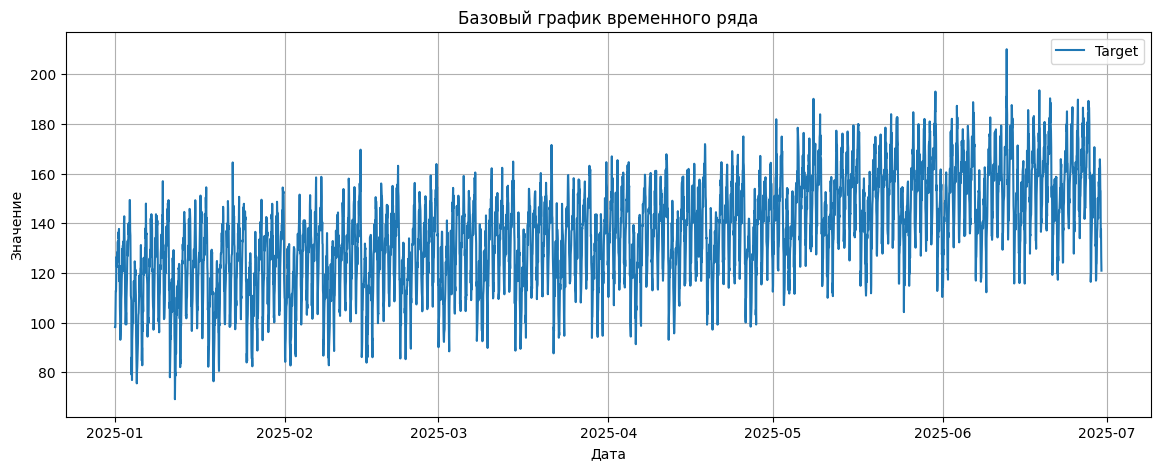

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df['date'], df['target'], label='Target')
plt.title('Базовый график временного ряда')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.show()

### Корректный temporal split

In [16]:
n = len(df)
train_size = int(n * 0.7)
val_size = int(n * 0.15)

train_df = df.iloc[:train_size].reset_index(drop=True)
val_df = df.iloc[train_size : train_size + val_size].reset_index(drop=True)
test_df = df.iloc[train_size + val_size :].reset_index(drop=True)

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

print(f"\nTrain range: {train_df['date'].min()} - {train_df['date'].max()}")
print(f"Val range:   {val_df['date'].min()} - {val_df['date'].max()}")
print(f"Test range:  {test_df['date'].min()} - {test_df['date'].max()}")

Train shape: (3024, 2)
Val shape:   (648, 2)
Test shape:  (648, 2)

Train range: 2025-01-01 00:00:00 - 2025-05-06 23:00:00
Val range:   2025-05-07 00:00:00 - 2025-06-02 23:00:00
Test range:  2025-06-03 00:00:00 - 2025-06-29 23:00:00


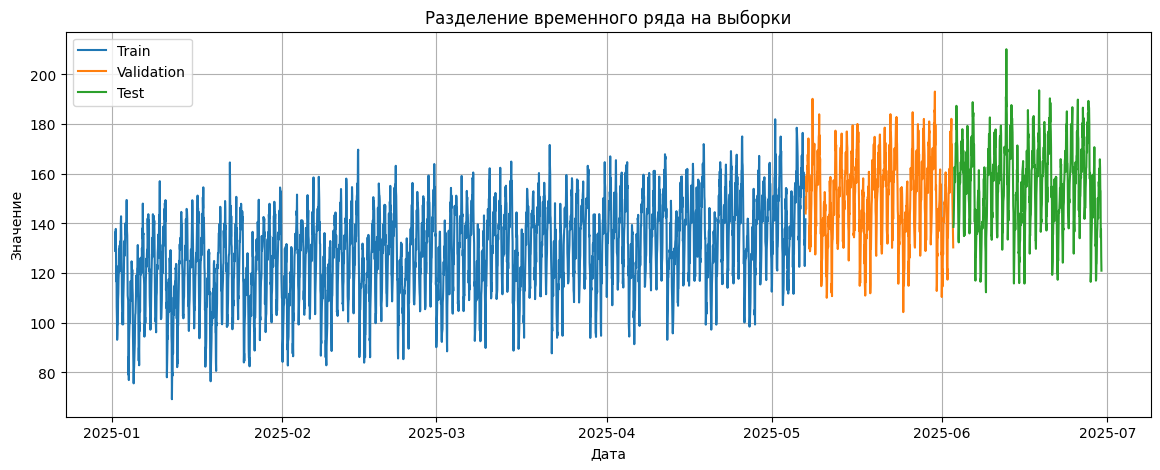

In [58]:
plt.figure(figsize=(14, 5))
plt.plot(train_df['date'], train_df['target'], label='Train')
plt.plot(val_df['date'], val_df['target'], label='Validation')
plt.plot(test_df['date'], test_df['target'], label='Test')
plt.title('Разделение временного ряда на выборки')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.savefig("artifacts/figures/series_split.png")
plt.show()

Random split здесь некорректен, потому что нам не нужно, чтобы данные перемешались и возника утечка данных (знание о будущих значениях).

### Признаки для baseline-моделей

In [18]:
def create_features(df_in):
    df_feat = df_in.copy()

    # Lags
    df_feat['lag_1'] = df_feat['target'].shift(1)
    df_feat['lag_7'] = df_feat['target'].shift(7)
    df_feat['lag_14'] = df_feat['target'].shift(14)

    # Rolling stats
    df_feat['rolling_mean_7'] = df_feat['target'].shift(1).rolling(window=7).mean()
    df_feat['rolling_std_7'] = df_feat['target'].shift(1).rolling(window=7).std()

    # Calendar features
    df_feat['dayofweek'] = df_feat['date'].dt.dayofweek
    df_feat['hour'] = df_feat['date'].dt.hour

    return df_feat

# Apply feature engineering
df_with_features = create_features(df).dropna().reset_index(drop=True)

# Update splits with features
n_feat = len(df_with_features)
train_idx = int(n_feat * 0.7)
val_idx = int(n_feat * 0.15)

train_df = df_with_features.iloc[:train_idx].reset_index(drop=True)
val_df = df_with_features.iloc[train_idx : train_idx + val_idx].reset_index(drop=True)
test_df = df_with_features.iloc[train_idx + val_idx :].reset_index(drop=True)

print(f"New Train shape: {train_df.shape}")
display(train_df.head())

New Train shape: (3014, 9)


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,14
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,15
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,16
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,17
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,18


### Оконное представление для GRU

In [22]:
WINDOW_SIZE = 28
BATCH_SIZE = 64

In [23]:
feature_cols = ['target', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'hour']

scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

train_scaled = scaler.transform(train_df[feature_cols])
val_scaled = scaler.transform(val_df[feature_cols])
test_scaled = scaler.transform(test_df[feature_cols])

In [24]:
class TSDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = torch.FloatTensor(data)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size, 0]
        return x, y

In [25]:
train_ds = TSDataset(train_scaled, WINDOW_SIZE)
val_ds = TSDataset(val_scaled, WINDOW_SIZE)
test_ds = TSDataset(test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [26]:
print(f"Train samples: {len(train_ds)}")
x_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {x_batch.shape}")
print(f"Batch Y shape: {y_batch.shape}")

Train samples: 2986
Batch X shape: torch.Size([64, 28, 8])
Batch Y shape: torch.Size([64])


### Базовые функции обучения и оценки

In [45]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    train_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output.squeeze(), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    return train_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    val_loss = 0
    y_true = []
    y_pred = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = criterion(output.squeeze(), y)
        val_loss += loss.item() * x.size(0)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(output.squeeze().cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    avg_loss = val_loss / len(loader.dataset)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return avg_loss, mae, rmse, mape


def train_model(model, train_loader, val_loader, epochs, lr, device, path="best_model.pth"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_loss": [], "val_mae": [], "val_rmse": [], "val_mape": []}
    best_val_mae = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_mae, val_rmse, val_mape = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)
        history["val_rmse"].append(val_rmse)
        history["val_mape"].append(val_mape)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_state = model.state_dict()

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_mae={val_mae:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## Эксперименты

### B1 (naive-last)

Наивный baseline, где прогноз равен последнему известному значению.

In [49]:
y_true_b1_val = val_df['target'].values
y_pred_b1_val = val_df['lag_1'].values

mae_b1_val = mean_absolute_error(y_true_b1_val, y_pred_b1_val)
rmse_b1_val = root_mean_squared_error(y_true_b1_val, y_pred_b1_val)
mape_b1_val = np.mean(np.abs((y_true_b1_val - y_pred_b1_val) / y_true_b1_val)) * 100

print(f"MAE:  {mae_b1_val:.4f}")
print(f"RMSE: {rmse_b1_val:.4f}")
print(f"MAPE: {mape_b1_val:.2f}%")

MAE:  6.4406
RMSE: 8.2035
MAPE: 4.39%


### B2 (moving-average)

Baseline на основе скользящего среднего по окну разумного размера.

In [50]:
y_true_b2_val = val_df['target'].values
y_pred_b2_val = val_df['rolling_mean_7'].values

mae_b2_val = mean_absolute_error(y_true_b2_val, y_pred_b2_val)
rmse_b2_val = root_mean_squared_error(y_true_b2_val, y_pred_b2_val)
mape_b2_val = np.mean(np.abs((y_true_b2_val - y_pred_b2_val) / y_true_b2_val)) * 100

print(f"MAE:  {mae_b2_val:.4f}")
print(f"RMSE: {rmse_b2_val:.4f}")
print(f"MAPE: {mape_b2_val:.2f}%")

MAE:  12.7266
RMSE: 15.2421
MAPE: 8.83%


### B3 (ridge-lag-features)

Ridge на лаговых, rolling- и календарных признаках.

In [51]:
features = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'dayofweek', 'hour']
target = 'target'

ridge_model = Ridge(random_state=SEED)
ridge_model.fit(train_df[features], train_df[target])

y_true_b3_val = val_df[target].values
y_pred_b3_val = ridge_model.predict(val_df[features])

mae_b3_val = mean_absolute_error(y_true_b3_val, y_pred_b3_val)
rmse_b3_val = root_mean_squared_error(y_true_b3_val, y_pred_b3_val)
mape_b3_val = np.mean(np.abs((y_true_b3_val - y_pred_b3_val) / y_true_b3_val)) * 100

print(f"MAE:  {mae_b3_val:.4f}")
print(f"RMSE: {rmse_b3_val:.4f}")
print(f"MAPE: {mape_b3_val:.2f}%")

MAE:  6.3597
RMSE: 7.8875
MAPE: 4.28%


### R1 (gru-forecast)

GRU на оконном представлении ряда.

In [39]:
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1, output_dim=1):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [40]:
INPUT_DIM = len(feature_cols)
HIDDEN_DIM = 64
NUM_LAYERS = 2
EPOCHS = 30
LR = 1e-3

In [46]:
model_r1 = GRUModel(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS)

history_r1 = train_model(
    model_r1,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    device=DEVICE
)

Epoch 01 | train_loss=0.3433 | val_loss=0.1927 | val_mae=0.3407
Epoch 02 | train_loss=0.1162 | val_loss=0.1505 | val_mae=0.2959
Epoch 03 | train_loss=0.1067 | val_loss=0.1640 | val_mae=0.3151
Epoch 04 | train_loss=0.1015 | val_loss=0.1403 | val_mae=0.2855
Epoch 05 | train_loss=0.0980 | val_loss=0.1328 | val_mae=0.2770
Epoch 06 | train_loss=0.0979 | val_loss=0.1235 | val_mae=0.2672
Epoch 07 | train_loss=0.0957 | val_loss=0.1225 | val_mae=0.2658
Epoch 08 | train_loss=0.0956 | val_loss=0.1179 | val_mae=0.2607
Epoch 09 | train_loss=0.0931 | val_loss=0.1475 | val_mae=0.2940
Epoch 10 | train_loss=0.0918 | val_loss=0.1303 | val_mae=0.2732
Epoch 11 | train_loss=0.0911 | val_loss=0.1233 | val_mae=0.2675
Epoch 12 | train_loss=0.0934 | val_loss=0.1546 | val_mae=0.3060
Epoch 13 | train_loss=0.0902 | val_loss=0.1179 | val_mae=0.2625
Epoch 14 | train_loss=0.0896 | val_loss=0.1458 | val_mae=0.2961
Epoch 15 | train_loss=0.0882 | val_loss=0.1606 | val_mae=0.3083
Epoch 16 | train_loss=0.0873 | val_loss=

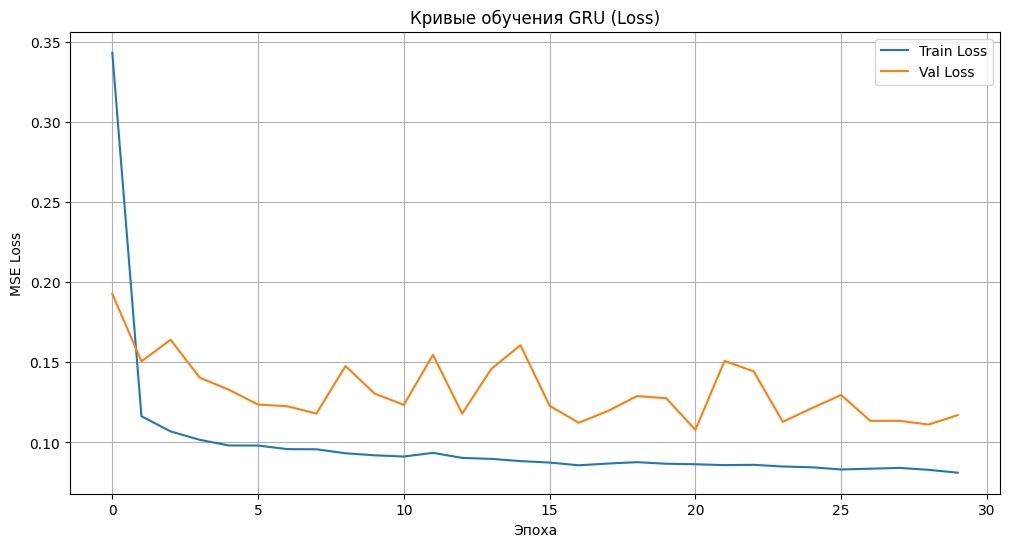

In [62]:
plt.figure(figsize=(12, 6))
plt.plot(history_r1['train_loss'], label='Train Loss')
plt.plot(history_r1['val_loss'], label='Val Loss')
plt.title('Кривые обучения GRU (Loss)')
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png")
plt.show()

In [52]:
val_loss, mae_r1_val, rmse_r1_val, mape_r1_val = evaluate(model_r1, val_loader, nn.MSELoss(), DEVICE)

print(f"MAE:  {mae_r1_val:.4f}")
print(f"RMSE: {rmse_r1_val:.4f}")
print(f"MAPE: {mape_r1_val:.2f}%")

MAE:  0.2557
RMSE: 0.3419
MAPE: 77.16%


In [55]:
torch.save(model_r1.state_dict(), 'artifacts/best_gru.pt')

In [56]:
config = {
    'architecture': 'GRU',
    'input_dim': INPUT_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
    'window_size': WINDOW_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LR,
    'seed': SEED,
    'device': str(DEVICE),
    'feature_cols': feature_cols,
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist()
}

with open('artifacts/best_gru_config.json', 'w') as f:
    json.dump(config, f, indent=4)

#### Лучший результат

In [53]:
val_results = {
    "Naive-last (B1)": mae_b1_val,
    "Moving-average (B2)": mae_b2_val,
    "Ridge (B3)": mae_b3_val,
    "GRU (R1)": mae_r1_val
}

best_model_name = min(val_results, key=val_results.get)
print(f"Лучшая модель по валидации: {best_model_name} (MAE: {val_results[best_model_name]:.4f})")

if best_model_name == "Naive-last (B1)":
    y_true_test = test_df['target'].values
    y_pred_test = test_df['lag_1'].values
    f_mae = mean_absolute_error(y_true_test, y_pred_test)
    f_rmse = root_mean_squared_error(y_true_test, y_pred_test)
    f_mape = np.mean(np.abs((y_true_test - y_pred_test) / y_true_test)) * 100

elif best_model_name == "Moving-average (B2)":
    y_true_test = test_df['target'].values
    y_pred_test = test_df['rolling_mean_7'].values
    f_mae = mean_absolute_error(y_true_test, y_pred_test)
    f_rmse = root_mean_squared_error(y_true_test, y_pred_test)
    f_mape = np.mean(np.abs((y_true_test - y_pred_test) / y_true_test)) * 100

elif best_model_name == "Ridge (B3)":
    y_true_test = test_df['target'].values
    y_pred_test = ridge_model.predict(test_df[features])
    f_mae = mean_absolute_error(y_true_test, y_pred_test)
    f_rmse = root_mean_squared_error(y_true_test, y_pred_test)
    f_mape = np.mean(np.abs((y_true_test - y_pred_test) / y_true_test)) * 100

else:
    _, f_mae, f_rmse, f_mape = evaluate(model_r1, test_loader, nn.MSELoss(), DEVICE)

print(f"Результаты на тестовой выборке ({best_model_name}):")
print(f"MAE:  {f_mae:.4f}")
print(f"RMSE: {f_rmse:.4f}")
print(f"MAPE: {f_mape:.2f}%")

Лучшая модель по валидации: GRU (R1) (MAE: 0.2557)
Результаты на тестовой выборке (GRU (R1)):
MAE:  0.2803
RMSE: 0.3695
MAPE: 47.80%


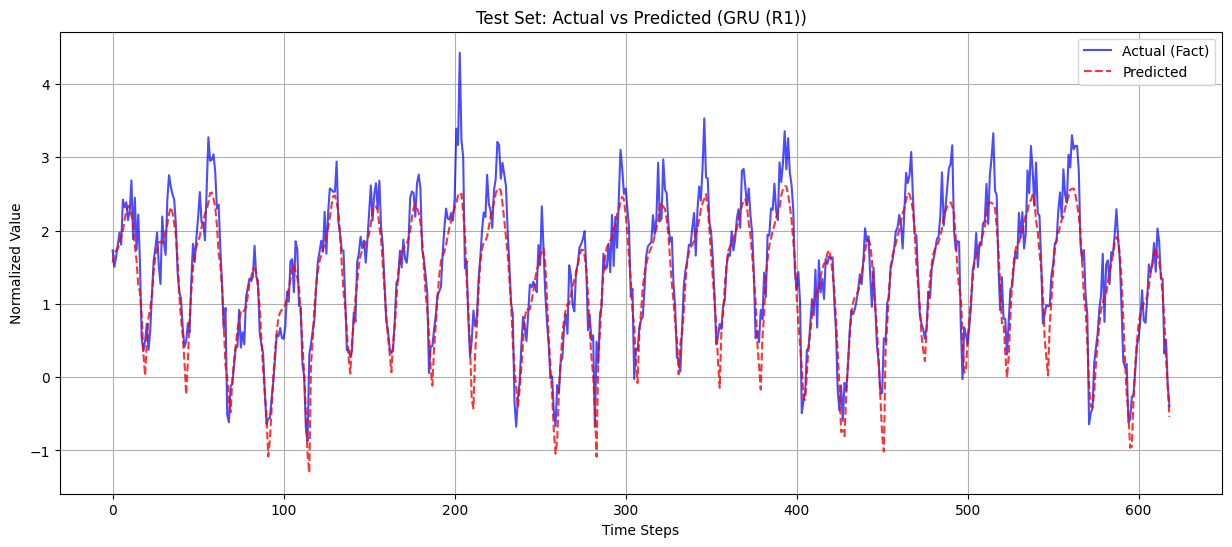

In [63]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    preds = []
    trues = []
    for x, y in loader:
        x = x.to(device)
        output = model(x)
        preds.extend(output.squeeze().cpu().numpy())
        trues.extend(y.numpy())
    return np.array(trues), np.array(preds)

y_true_test, y_pred_test = get_predictions(model_r1, test_loader, DEVICE)

plt.figure(figsize=(15, 6))
plt.plot(y_true_test, label='Actual (Fact)', color='blue', alpha=0.7)
plt.plot(y_pred_test, label='Predicted', color='red', linestyle='--', alpha=0.8)
plt.title(f'Test Set: Actual vs Predicted ({best_model_name})')
plt.xlabel('Time Steps')
plt.ylabel('Normalized Value')
plt.legend()
plt.savefig("artifacts/figures/best_forecast_test.png")
plt.show()

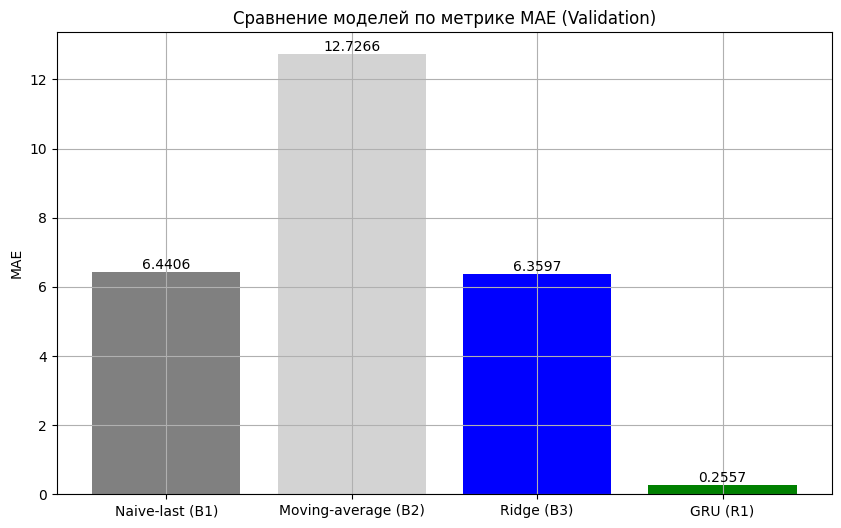

In [61]:
plt.figure(figsize=(10, 6))
model_names = list(val_results.keys())
mae_values = list(val_results.values())

bars = plt.bar(model_names, mae_values, color=['gray', 'lightgray', 'blue', 'green'])
plt.title('Сравнение моделей по метрике MAE (Validation)')
plt.ylabel('MAE')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 4), va='bottom', ha='center')

plt.savefig("artifacts/figures/baselines_compare.png")
plt.show()

In [65]:
import pandas as pd

runs_data = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": 1,
        "horizon": 1,
        "model_summary": "Naive-last",
        "features_summary": "lag_1",
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": mae_b1_val,
        "best_val_rmse": rmse_b1_val,
        "best_val_mape": mape_b1_val,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Baseline: prediction = previous value"
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": 7,
        "horizon": 1,
        "model_summary": "Moving Average",
        "features_summary": "rolling_mean_7",
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": mae_b2_val,
        "best_val_rmse": rmse_b2_val,
        "best_val_mape": mape_b2_val,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Baseline: weekly rolling mean"
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": 14,
        "horizon": 1,
        "model_summary": "Ridge Regression",
        "features_summary": "lags, rolling, calendar",
        "scaler": "StandardScaler (implicit in data prep)",
        "optimizer": "Analytical",
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": mae_b3_val,
        "best_val_rmse": rmse_b3_val,
        "best_val_mape": mape_b3_val,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Classical linear model with feature engineering"
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": WINDOW_SIZE,
        "horizon": 1,
        "model_summary": f"GRU (hidden={HIDDEN_DIM}, layers={NUM_LAYERS})",
        "features_summary": "windowed sequences of all features",
        "scaler": "StandardScaler",
        "optimizer": "Adam",
        "lr": LR,
        "epochs_trained": EPOCHS,
        "best_val_mae": mae_r1_val,
        "best_val_rmse": rmse_r1_val,
        "best_val_mape": mape_r1_val,
        "test_mae": f_mae,
        "test_rmse": f_rmse,
        "test_mape": f_mape,
        "notes": "Recurrent Neural Network approach"
    }
]

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv("artifacts/runs.csv", na_rep="", index=False)